In [2]:
import pandas as pd

# Let's inspect how the data is separated (UCI datasets often use semicolons ';')
try:
    df = pd.read_csv('../data/raw/student_data.csv', sep=';')
    print("✅ Successfully loaded with semicolon separator!")
except Exception as e:
    df = pd.read_csv('../data/raw/student_data.csv')
    print("✅ Loaded with default comma separator!")

# Show the first 5 rows and the columns we have
print(f"Dataset Shape: {df.shape}")
df.head()

✅ Successfully loaded with semicolon separator!
Dataset Shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Target mapped: 1 for Dropout, 0 for Non-Dropout.


C:\Users\RRH\AppData\Local\Temp\ipykernel_3276\1687812833.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')


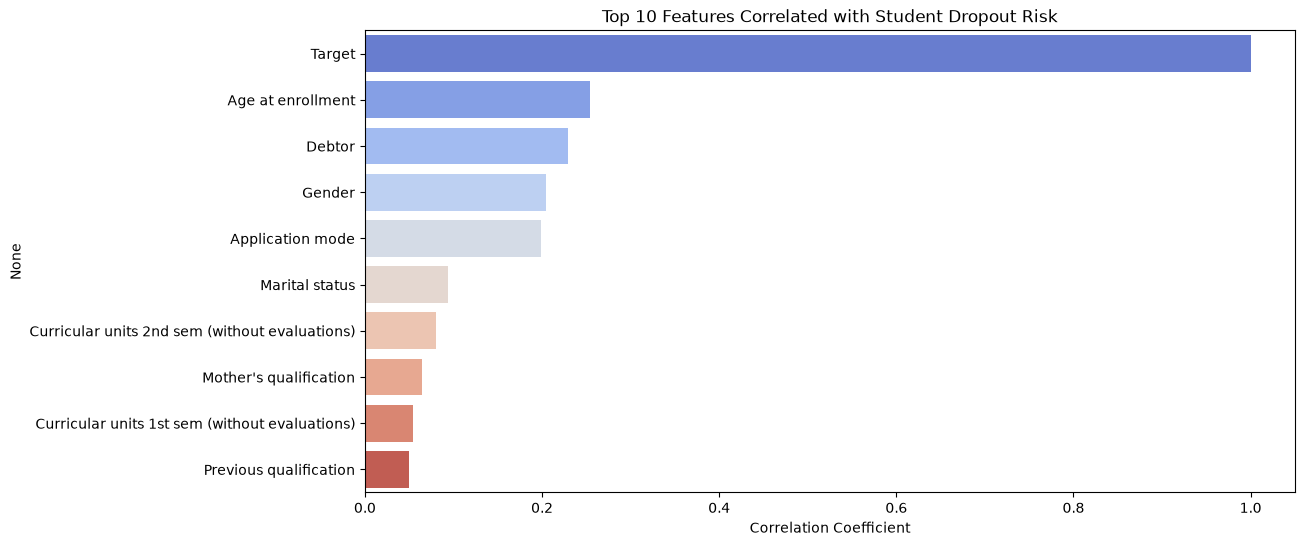

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert text target to binary numbers (1 = Dropout, 0 = Stayed/Graduated)
if 'Target' in df.columns:
    df['Target'] = df['Target'].apply(lambda x: 1 if str(x).strip() == 'Dropout' else 0)
    print("Target mapped: 1 for Dropout, 0 for Non-Dropout.")
else:
    # If columns have underscores like 'Target_Variable'
    print("Columns available:", df.columns)

# Plot the top correlations
plt.figure(figsize=(12, 6))
top_corr = df.corr()['Target'].sort_values(ascending=False).head(10)
sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')
plt.title('Top 10 Features Correlated with Student Dropout Risk')
plt.xlabel('Correlation Coefficient')
plt.show()

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

def preprocess_and_save_production(df):
    print("✨ Starting Production Preprocessing Pipeline...")
    
    # 1. Standardize column names (stripping trailing whitespace, replacing spaces with underscores)
    df.columns = [col.strip().replace(' ', '_') for col in df.columns]
    
    # 2. Map target classes to Binary Dropout Risk
    if 'Target' in df.columns:
        df['Target'] = df['Target'].apply(lambda x: 1 if str(x).strip() == 'Dropout' else 0)
    else:
        raise KeyError("Target column missing from dataset!")
    
    # 3. Split Features and Target
    X = df.drop(columns=['Target', 'Dropout_Risk'], errors='ignore') # ignore Dropout_Risk if created in EDA steps
    y = df['Target']
    
    # 4. Explicitly isolate continuous numerical features that genuinely require scaling
    # Any feature not in this list is treated as a categorical/binary indicator
    numerical_cols = [
        'Previous_qualification_(grade)',
        'Admission_grade',
        'Age_at_enrollment',
        'Curricular_units_1st_sem_(credited)',
        'Curricular_units_1st_sem_(enrolled)',
        'Curricular_units_1st_sem_(evaluations)',
        'Curricular_units_1st_sem_(approved)',
        'Curricular_units_1st_sem_(grade)',
        'Curricular_units_1st_sem_(without_evaluations)',
        'Curricular_units_2nd_sem_(credited)',
        'Curricular_units_2nd_sem_(enrolled)',
        'Curricular_units_2nd_sem_(evaluations)',
        'Curricular_units_2nd_sem_(approved)',
        'Curricular_units_2nd_sem_(grade)',
        'Curricular_units_2nd_sem_(without_evaluations)',
        'Unemployment_rate',
        'Inflation_rate',
        'GDP'
    ]
    
    # Dynamically discover all remaining categorical/encoded columns
    categorical_cols = [col for col in X.columns if col not in numerical_cols]
    
    print(f"📊 Identified {len(numerical_cols)} numerical features for scaling.")
    print(f"🏷️ Identified {len(categorical_cols)} categorical/binary features to preserve.")
    
    # 5. 80/20 Stratified Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Ensure processed directory exists
    os.makedirs('../data/processed', exist_ok=True)
    
    # --- TRACK A: Save RAW unscaled data (XGBoost / Random Forest) ---
    X_train.to_csv('../data/processed/X_train.csv', index=False)
    X_test.to_csv('../data/processed/X_test.csv', index=False)
    
    # --- TRACK B: Scale ONLY numerical columns (Logistic Regression) ---
    # Create copies to avoid overwriting raw splits
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()
    
    scaler = StandardScaler()
    
    # Fit and transform ONLY the continuous features
    X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
    X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])
    
    # Save the correctly partitioned scaled tracks
    X_train_scaled.to_csv('../data/processed/X_train_scaled.csv', index=False)
    X_test_scaled.to_csv('../data/processed/X_test_scaled.csv', index=False)
    
    # Save Shared Targets
    y_train.to_csv('../data/processed/y_train.csv', index=False)
    y_test.to_csv('../data/processed/y_test.csv', index=False)
    
    # Save scaler artifact (it will know to only expect/transform the numerical subset later)
    os.makedirs('../models', exist_ok=True)
    joblib.dump(scaler, '../models/scaler.pkl')
    
    print("✅ Preprocessing complete! Outputs successfully generated with isolated scaling tracks.")

df = pd.read_csv('../data/raw/student_data.csv', sep=';')

preprocess_and_save_production(df)

✨ Starting Production Preprocessing Pipeline...
📊 Identified 18 numerical features for scaling.
🏷️ Identified 18 categorical/binary features to preserve.
✅ Preprocessing complete! Outputs successfully generated with isolated scaling tracks.


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/raw/student_data.csv', sep=';')
df.columns = [col.strip().replace(' ', '_') for col in df.columns]

print("Shape:", df.shape)
print("\nMissing values per column:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDtypes:\n", df.dtypes.value_counts())

# Sanity check on target distribution before mapping
print("\nRaw target classes:\n", df['Target'].value_counts())

Shape: (4424, 37)

Missing values per column:
 Series([], dtype: int64)

Duplicate rows: 0

Dtypes:
 int64      29
float64     7
str         1
Name: count, dtype: int64

Raw target classes:
 Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


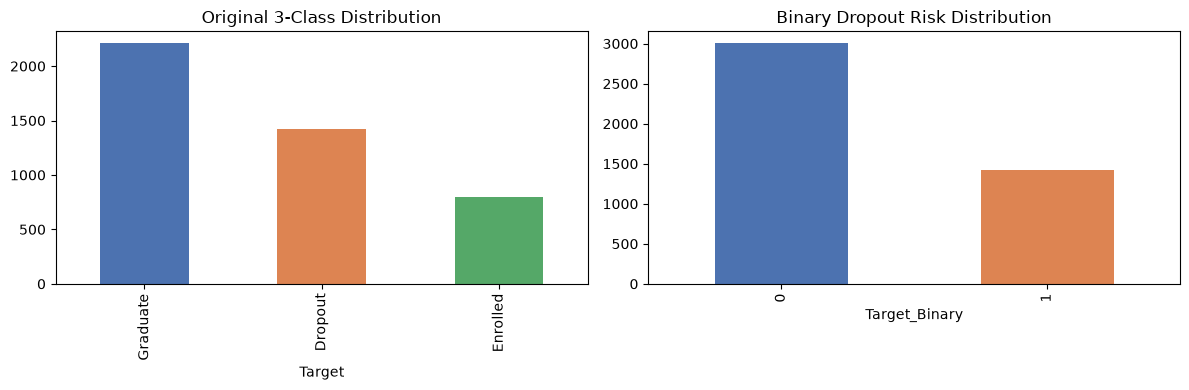


Class proportions:
 Target_Binary
0    0.678797
1    0.321203
Name: proportion, dtype: float64


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

df['Target_Binary'] = df['Target'].apply(lambda x: 1 if str(x).strip() == 'Dropout' else 0)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df['Target'].value_counts().plot(kind='bar', ax=ax[0], color=['#4C72B0', '#DD8452', '#55A868'])
ax[0].set_title('Original 3-Class Distribution')

df['Target_Binary'].value_counts().plot(kind='bar', ax=ax[1], color=['#4C72B0', '#DD8452'])
ax[1].set_title('Binary Dropout Risk Distribution')
plt.tight_layout()
plt.show()

imbalance_ratio = df['Target_Binary'].value_counts(normalize=True)
print("\nClass proportions:\n", imbalance_ratio)

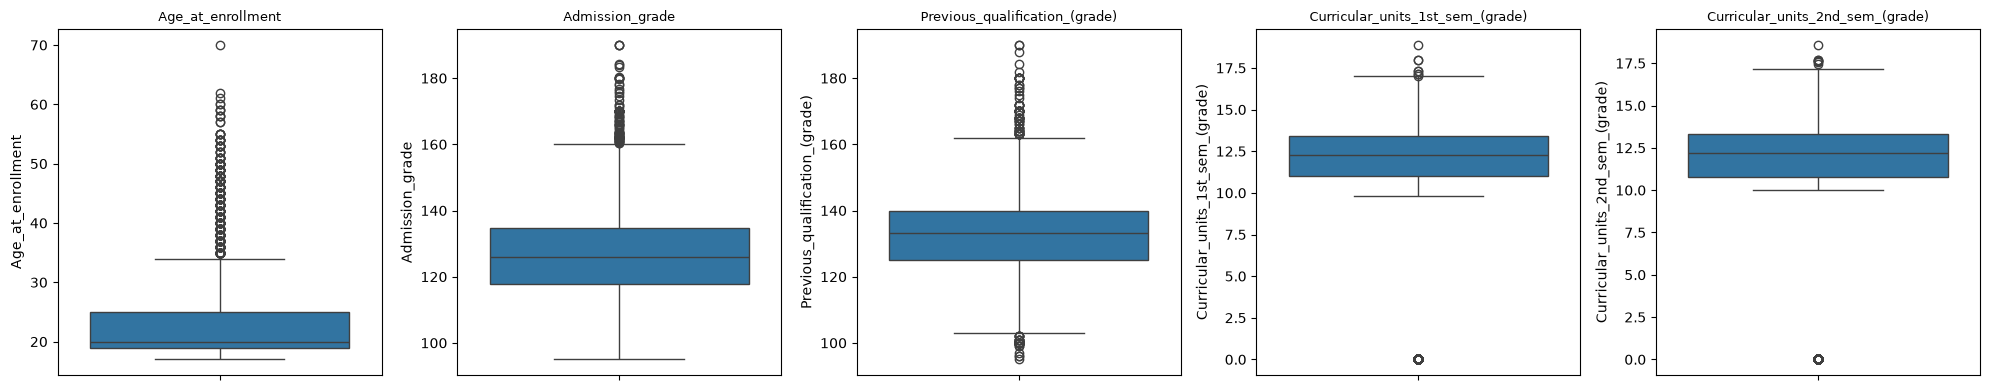

Dropout rate for students aged 41+: 0.5066666666666667
Dropout rate overall: 0.3212025316455696


In [3]:
numerical_cols = [
    'Age_at_enrollment', 'Admission_grade', 'Previous_qualification_(grade)',
    'Curricular_units_1st_sem_(grade)', 'Curricular_units_2nd_sem_(grade)'
]

fig, axes = plt.subplots(1, len(numerical_cols), figsize=(20, 4))
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

# Check whether age outliers correlate with dropout risk (rather than just flagging them)
age_threshold = df['Age_at_enrollment'].quantile(0.95)
older_students = df[df['Age_at_enrollment'] >= age_threshold]
print(f"Dropout rate for students aged {age_threshold:.0f}+:", 
      older_students['Target_Binary'].mean())
print("Dropout rate overall:", df['Target_Binary'].mean())

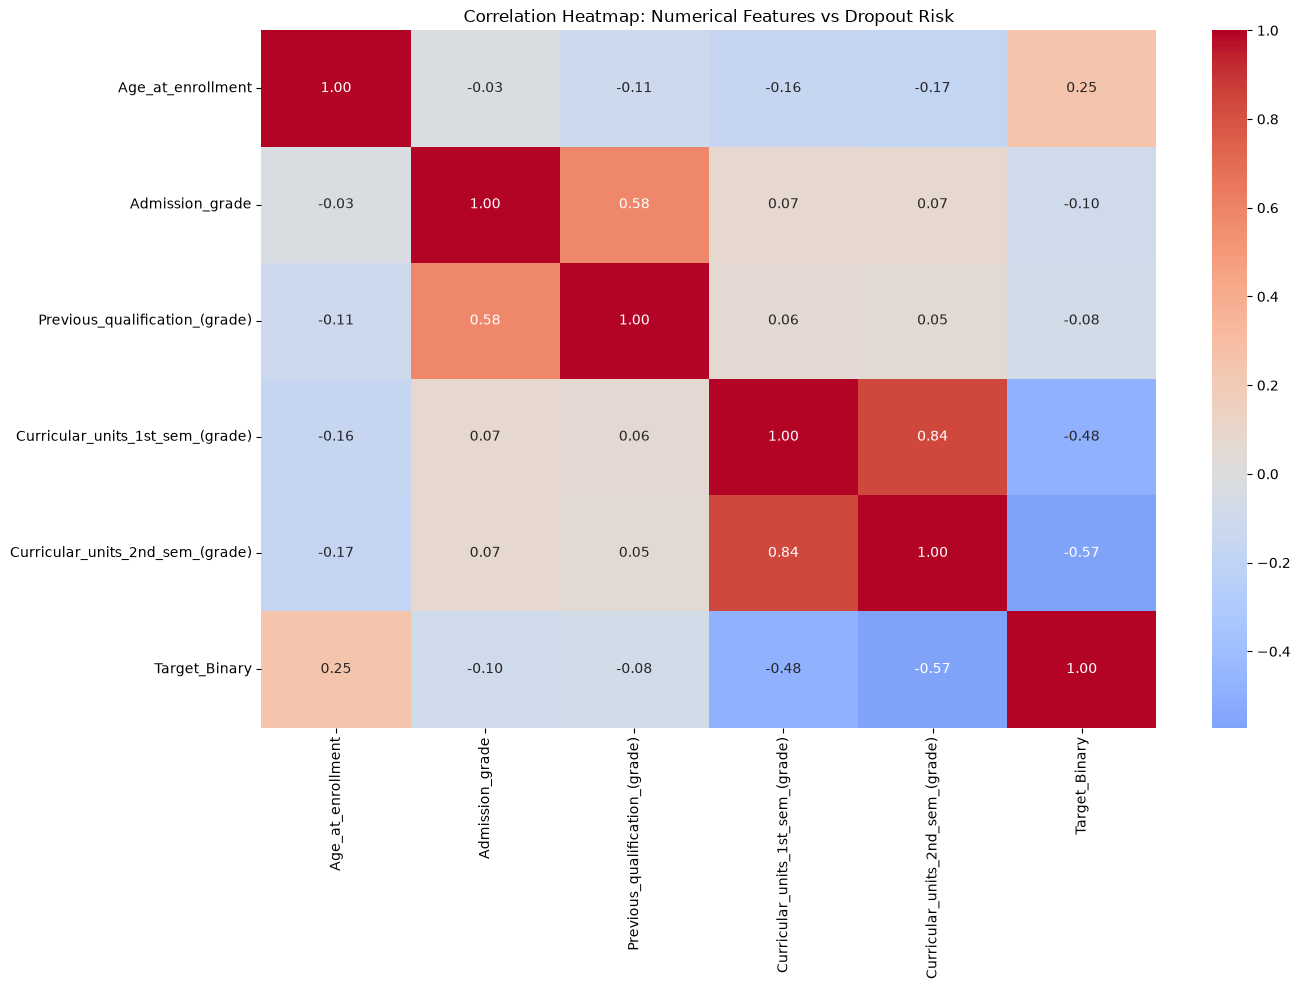

In [4]:
plt.figure(figsize=(14, 10))
corr = df[numerical_cols + ['Target_Binary']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: Numerical Features vs Dropout Risk')
plt.tight_layout()
plt.show()

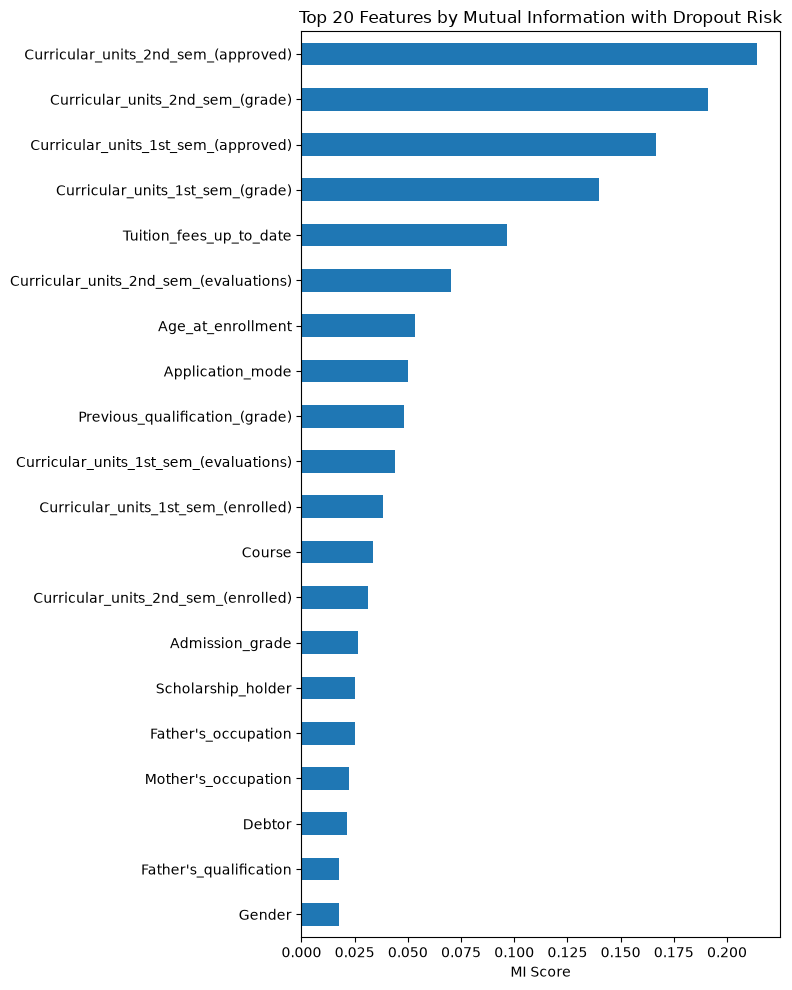

Curricular_units_2nd_sem_(approved)       0.214191
Curricular_units_2nd_sem_(grade)          0.190904
Curricular_units_1st_sem_(approved)       0.166746
Curricular_units_1st_sem_(grade)          0.139983
Tuition_fees_up_to_date                   0.096742
Curricular_units_2nd_sem_(evaluations)    0.070179
Age_at_enrollment                         0.053254
Application_mode                          0.050019
Previous_qualification_(grade)            0.048279
Curricular_units_1st_sem_(evaluations)    0.043817
Curricular_units_1st_sem_(enrolled)       0.038281
Course                                    0.033397
Curricular_units_2nd_sem_(enrolled)       0.031240
Admission_grade                           0.026504
Scholarship_holder                        0.025333
Father's_occupation                       0.025292
Mother's_occupation                       0.022118
Debtor                                    0.021217
Father's_qualification                    0.017495
Gender                         

In [5]:
from sklearn.feature_selection import mutual_info_classif

X = df.drop(columns=['Target', 'Target_Binary'], errors='ignore')
y = df['Target_Binary']

# Encode any remaining categorical columns for MI computation only (not the actual pipeline)
X_encoded = X.copy()
for col in X_encoded.select_dtypes(include='object').columns:
    X_encoded[col] = X_encoded[col].astype('category').cat.codes

mi_scores = mutual_info_classif(X_encoded, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X_encoded.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
mi_series.head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 20 Features by Mutual Information with Dropout Risk')
plt.xlabel('MI Score')
plt.tight_layout()
plt.show()

print(mi_series.head(20))

## 6. Low-Variance / Constant Column Verification
**Objective:** Identify features with heavily skewed single-value concentrations (>95%). While tree models (XGBoost) easily bypass non-informative features, linear architectures can suffer from noise saturation. We map these diagnostics here but reserve dropping decisions for final model validation.

In [7]:
import pandas as pd

X_train = pd.read_csv('../data/processed/X_train.csv')

# Check near-constant / low-variance columns
low_variance_cols = []
for col in X_train.select_dtypes(include='number').columns:
    top_freq = X_train[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.95:
        low_variance_cols.append((col, top_freq))

print("Columns with >95% single-value concentration:")
for col, freq in low_variance_cols:
    print(f"  {col}: {freq:.2%}")

Columns with >95% single-value concentration:
  Nacionality: 97.63%
  Educational_special_needs: 98.84%
  International: 97.63%


## 7. Variance Inflation Factor (VIF) Assessment
**Objective:** Quantify the scale of multicollinearity among continuous academic features. A VIF value exceeding ~10 indicates severe redundancy, which signals potential instability for our Logistic Regression baseline coefficients.

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

numerical_cols = [
    'Age_at_enrollment', 'Admission_grade', 'Previous_qualification_(grade)',
    'Curricular_units_1st_sem_(grade)', 'Curricular_units_2nd_sem_(grade)',
    'Curricular_units_1st_sem_(approved)', 'Curricular_units_2nd_sem_(approved)'
]

vif_data = pd.DataFrame()
vif_data['feature'] = numerical_cols
vif_data['VIF'] = [variance_inflation_factor(X_train[numerical_cols].values, i) 
                    for i in range(len(numerical_cols))]
print(vif_data.sort_values('VIF', ascending=False))

                               feature         VIF
1                      Admission_grade  110.002289
2       Previous_qualification_(grade)  109.512375
6  Curricular_units_2nd_sem_(approved)   23.158009
3     Curricular_units_1st_sem_(grade)   22.705021
4     Curricular_units_2nd_sem_(grade)   22.673050
5  Curricular_units_1st_sem_(approved)   21.537790
0                    Age_at_enrollment    9.819699


## 8. Strategic Feature Engineering
**Objective:** Synthesize a new binary metric (`Had_Semester_Failure`) to flag if a student failed to pass a single module in either the 1st or 2nd semester. To prevent train-test data leakage, this transformation is applied universally and identically across all multi-track files.

In [9]:
# Previous Failures Flag — did the student fail to get any units approved in either semester?
X_train['Had_Semester_Failure'] = (
    (X_train['Curricular_units_1st_sem_(approved)'] == 0) |
    (X_train['Curricular_units_2nd_sem_(approved)'] == 0)
).astype(int)

print(X_train['Had_Semester_Failure'].value_counts(normalize=True))

Had_Semester_Failure
0    0.790901
1    0.209099
Name: proportion, dtype: float64


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
X_train_scaled = pd.read_csv('../data/processed/X_train_scaled.csv')
X_test_scaled = pd.read_csv('../data/processed/X_test_scaled.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

models = {
    'Logistic Regression': (LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42), 
                             X_train_scaled, X_test_scaled),
    'Decision Tree': (DecisionTreeClassifier(class_weight='balanced', random_state=42), 
                       X_train, X_test),
    'Random Forest': (RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=200), 
                       X_train, X_test),
    'XGBoost': (XGBClassifier(scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(), 
                               random_state=42, eval_metric='logloss'), 
                X_train, X_test)
}

trained_models = {}
for name, (model, X_tr, X_te) in models.items():
    model.fit(X_tr, y_train)
    trained_models[name] = model
    print(f"{name} trained.")

c:\Users\RRH\miniconda3\envs\student_dropout_env\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression trained.
Decision Tree trained.
Random Forest trained.
XGBoost trained.


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []
for name, (model, X_tr, X_te) in models.items():
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC
      Random Forest  0.879096   0.821818 0.795775  0.808587 0.930538
            XGBoost  0.876836   0.815884 0.795775  0.805704 0.923385
Logistic Regression  0.853107   0.745223 0.823944  0.782609 0.920455
      Decision Tree  0.803390   0.693662 0.693662  0.693662 0.774452


In [13]:
import os

os.makedirs('../results', exist_ok=True)
results_df.to_csv('../results/baseline_results.csv', index=False)
print("Saved to ../results/baseline_results.csv")

Saved to ../results/baseline_results.csv


In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

for leaf in [1, 2, 3, 5]:
    model = RandomForestClassifier(
        n_estimators=381, max_depth=16, min_samples_split=4,
        min_samples_leaf=leaf, max_features='log2',
        class_weight='balanced', random_state=42
    )
    model.fit(X_train, y_train)
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f"min_samples_leaf={leaf}: Train={train_auc:.4f}, Test={test_auc:.4f}, Gap={train_auc - test_auc:.4f}")

min_samples_leaf=1: Train=0.9995, Test=0.9320, Gap=0.0675
min_samples_leaf=2: Train=0.9980, Test=0.9314, Gap=0.0666
min_samples_leaf=3: Train=0.9934, Test=0.9322, Gap=0.0612
min_samples_leaf=5: Train=0.9822, Test=0.9309, Gap=0.0513
